# World Cup Upset Classifier
Trains an XGBoost model on 150 years of international football results to predict upset probability.

**Features**: all-time ELO diff, 3-year form ELO diff, confederation context, venue, match stakes  
**Evaluation**: Brier score, ROC-AUC, calibration curve, SHAP explainability  

Prerequisite: `classifier_features.csv` must exist (generated by `elo_engine.py`)

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, RocCurveDisplay
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})
print('All imports OK')

All imports OK


## 1. Load & inspect

In [2]:
df = pd.read_csv('classifier_features.csv', parse_dates=['date'])
print(f'Rows: {len(df):,}   Columns: {len(df.columns)}')
df.head(3)

Rows: 49,365   Columns: 20


,date,home_team,away_team,tournament,elo_diff,elo_home,elo_away,form_elo_diff,form_elo_home,form_elo_away,conf_home,conf_away,same_conf,conf_k_mult,is_neutral,tournament_k,pre_prob_home,pre_prob_away,target,upset_score
0,1872-11-30,Scotland,England,Friendly,0.0,1500.0,1500.0,0.0,1500.0,1500.0,UEFA,UEFA,1,1.0,0,5.0,0.6401,0.3599,0,0.0000
1,1873-03-08,England,Scotland,Friendly,1.4,1500.7,1499.3,0.0,1500.0,1500.0,UEFA,UEFA,1,1.0,0,5.0,0.6419,0.3581,0,0.3581
2,1874-03-07,Scotland,England,Friendly,-7.3,1496.3,1503.7,-8.2,1495.9,1504.1,UEFA,UEFA,1,1.0,0,5.0,0.6303,0.3697,0,0.3697


In [3]:
# Sanity check: upsets should have negative elo_diff (underdog won)
check_cols = ['elo_diff', 'form_elo_diff', 'pre_prob_home', 'conf_k_mult', 'same_conf']
print('=== Mean feature values by upset/non-upset ===')
print(df.groupby('target')[check_cols].mean().round(3))
print(f"\nUpset rate : {df['target'].mean():.1%}")
print(f"Total upsets: {df['target'].sum():,}")

=== Mean feature values by upset/non-upset ===
        elo_diff  form_elo_diff  pre_prob_home  conf_k_mult  same_conf
target                                                                
0         21.119         11.653          0.607        0.929      0.589
1        -35.965        -19.627          0.544        0.925      0.582

Upset rate : 19.9%
Total upsets: 9,846


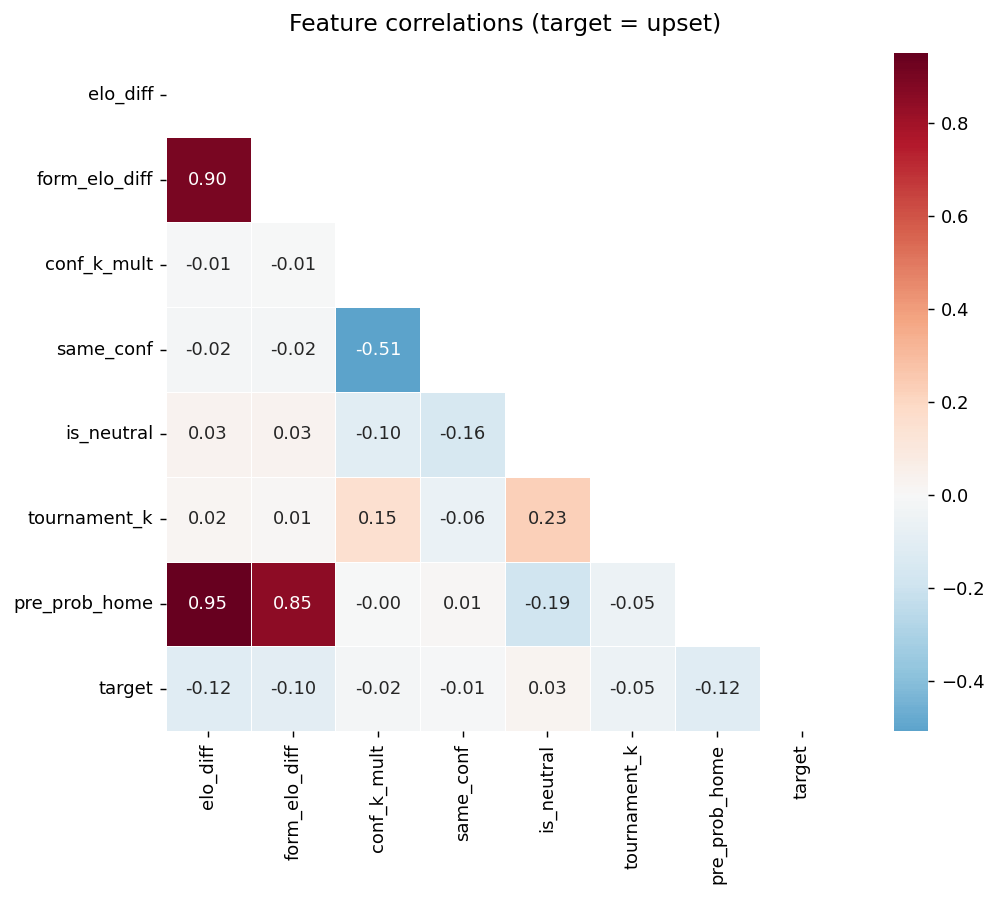

In [4]:
# Correlation heatmap
FEATURE_COLS = [
    'elo_diff', 'form_elo_diff', 'conf_k_mult', 'same_conf',
    'is_neutral', 'tournament_k', 'pre_prob_home',
]
TARGET_COL = 'target'

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[FEATURE_COLS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature correlations (target = upset)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 2. Temporal train / test split
Train on matches before 2010, test on 2010 onward. Never use random splits for time-series data.

In [5]:
SPLIT_DATE = '2010-01-01'

train = df[df['date'] < SPLIT_DATE].dropna(subset=FEATURE_COLS)
test  = df[df['date'] >= SPLIT_DATE].dropna(subset=FEATURE_COLS)

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f'Train: {len(X_train):,} rows  ({y_train.mean():.1%} upsets)')
print(f'Test:  {len(X_test):,}  rows  ({y_test.mean():.1%} upsets)')

Train: 33,588 rows  (20.7% upsets)
Test:  15,777  rows  (18.2% upsets)


## 3. Baseline — logistic regression

In [6]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]

lr_brier = brier_score_loss(y_test, lr_probs)
lr_auc   = roc_auc_score(y_test, lr_probs)
print(f'Logistic Regression  |  Brier: {lr_brier:.4f}  |  AUC: {lr_auc:.4f}')

coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr_pipe.named_steps['clf'].coef_[0]
}).sort_values('coefficient')
print('\nCoefficients (negative = pushes toward upset):')
print(coef_df.to_string(index=False))

Logistic Regression  |  Brier: 0.1496  |  AUC: 0.5890

Coefficients (negative = pushes toward upset):
      feature  coefficient
     elo_diff    -0.491998
 tournament_k    -0.179713
    same_conf    -0.027808
  conf_k_mult    -0.024245
form_elo_diff     0.073957
pre_prob_home     0.097313
   is_neutral     0.141807


## 4. XGBoost classifier

In [7]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {scale_pos_weight:.2f}  (neg={neg:,}, pos={pos:,})')

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_brier = brier_score_loss(y_test, xgb_probs)
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print(f'\nXGBoost              |  Brier: {xgb_brier:.4f}  |  AUC: {xgb_auc:.4f}')
print(f'Logistic Regression  |  Brier: {lr_brier:.4f}  |  AUC: {lr_auc:.4f}')
print(f'\nXGBoost Brier improvement: {(lr_brier - xgb_brier) / lr_brier:.1%}')

scale_pos_weight = 3.82  (neg=26,619, pos=6,969)

XGBoost              |  Brier: 0.2068  |  AUC: 0.6913
Logistic Regression  |  Brier: 0.1496  |  AUC: 0.5890

XGBoost Brier improvement: -38.2%


## 5. Calibration & ROC curves

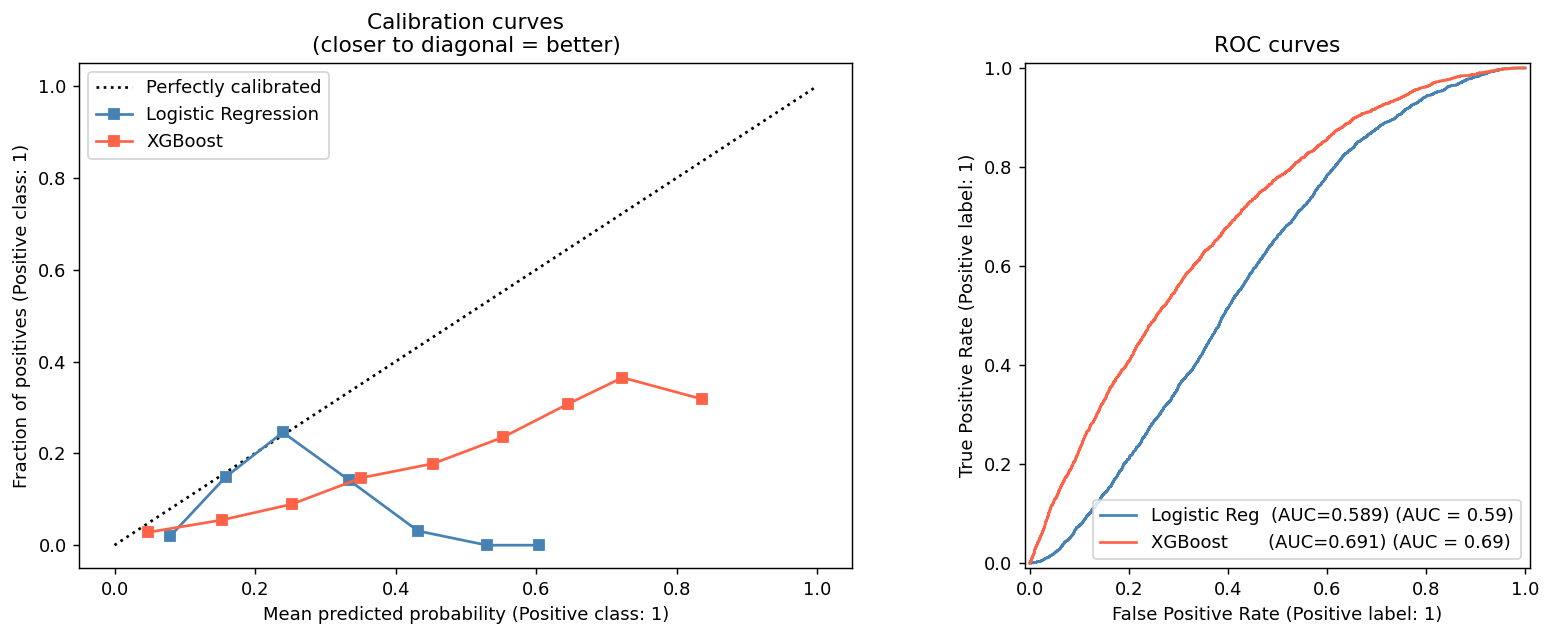

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

CalibrationDisplay.from_predictions(y_test, lr_probs,  n_bins=10, ax=axes[0],
                                     name='Logistic Regression', color='steelblue')
CalibrationDisplay.from_predictions(y_test, xgb_probs, n_bins=10, ax=axes[0],
                                     name='XGBoost', color='tomato')
axes[0].set_title('Calibration curves\n(closer to diagonal = better)', fontsize=12)
axes[0].legend(fontsize=10)

RocCurveDisplay.from_predictions(y_test, lr_probs,  ax=axes[1],
                                  name=f'Logistic Reg  (AUC={lr_auc:.3f})', color='steelblue')
RocCurveDisplay.from_predictions(y_test, xgb_probs, ax=axes[1],
                                  name=f'XGBoost       (AUC={xgb_auc:.3f})', color='tomato')
axes[1].set_title('ROC curves', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('calibration_roc.png', bbox_inches='tight')
plt.show()

## 6. SHAP explainability
Applies a config patch to work around a known SHAP 0.49.x / XGBoost version mismatch with base_score formatting.

In [9]:
# Patch: SHAP 0.49.x can't parse XGBoost's '[5E-1]' base_score string.
# Rewrite the booster config with a plain float before handing it to SHAP.
booster = xgb.get_booster()
cfg = json.loads(booster.save_config())
cfg['learner']['learner_model_param']['base_score'] = '0.5'
booster.load_config(json.dumps(cfg))

explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)
print('SHAP values computed — shape:', np.array(shap_values).shape)

ValueError: could not convert string to float: '[5E-1]'

In [ ]:
# Global bar chart: which features matter most overall
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  feature_names=FEATURE_COLS, show=False)
plt.title('SHAP feature importance — global', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()

In [10]:
# Beeswarm: direction AND magnitude — red = high feature value, blue = low
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURE_COLS, show=False)
plt.title('SHAP beeswarm — feature impact direction', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

NameError: name 'shap_values' is not defined

<Figure size 1170x650 with 0 Axes>

## 7. World Cup holdout backtest

In [11]:
wc_test = test[
    test['tournament'].str.contains('FIFA World Cup', na=False) &
    ~test['tournament'].str.contains('qualif', case=False, na=False)
]
X_wc = wc_test[FEATURE_COLS].dropna()
y_wc = wc_test.loc[X_wc.index, TARGET_COL]

wc_probs = xgb.predict_proba(X_wc)[:, 1]
print(f'World Cup holdout   |  Brier: {brier_score_loss(y_wc, wc_probs):.4f}  |  AUC: {roc_auc_score(y_wc, wc_probs):.4f}')
print(f'All-test set        |  Brier: {xgb_brier:.4f}  |  AUC: {xgb_auc:.4f}')
print(f'\nWC matches in test: {len(X_wc):,}  |  Upset rate: {y_wc.mean():.1%}')

World Cup holdout   |  Brier: 0.2467  |  AUC: 0.5682
All-test set        |  Brier: 0.2068  |  AUC: 0.6913

WC matches in test: 256  |  Upset rate: 24.2%


In [12]:
wc_results = wc_test.loc[X_wc.index].copy()
wc_results['upset_prob'] = (wc_probs * 100).round(1)

display_cols = ['date', 'home_team', 'away_team', 'elo_diff', 'upset_prob']

print('=== Biggest predicted upsets that actually happened ===')
true_upsets = wc_results[wc_results['target'] == 1].sort_values('upset_prob', ascending=False)
print(true_upsets[display_cols].head(15).to_string(index=False))

print('\n=== Upsets the model missed (low predicted probability) ===')
missed = wc_results[wc_results['target'] == 1].sort_values('upset_prob')
print(missed[display_cols].head(10).to_string(index=False))

=== Biggest predicted upsets that actually happened ===
      date    home_team     away_team  elo_diff  upset_prob
2022-11-27        Japan    Costa Rica     118.7   78.500000
2018-07-10       France       Belgium      -8.4   70.199997
2010-07-11  Netherlands         Spain       4.6   68.400002
2014-06-22      Belgium        Russia      -4.9   68.300003
2018-07-11      Croatia       England     -30.2   67.800003
2018-06-18       Sweden   South Korea     -11.3   65.800003
2010-06-23    Australia        Serbia     -20.3   65.699997
2014-06-19     Colombia   Ivory Coast     -23.9   65.699997
2010-06-21        Chile   Switzerland      -8.7   65.199997
2014-07-01      Belgium United States     -28.4   64.199997
2010-06-17       Greece       Nigeria     -75.2   63.099998
2010-07-02  Netherlands        Brazil     -43.9   61.400002
2010-06-16     Honduras         Chile       0.4   60.700001
2010-06-16 South Africa       Uruguay     -94.6   60.700001
2022-12-17      Croatia       Morocco     -4

## 8. All-time upset leaderboard

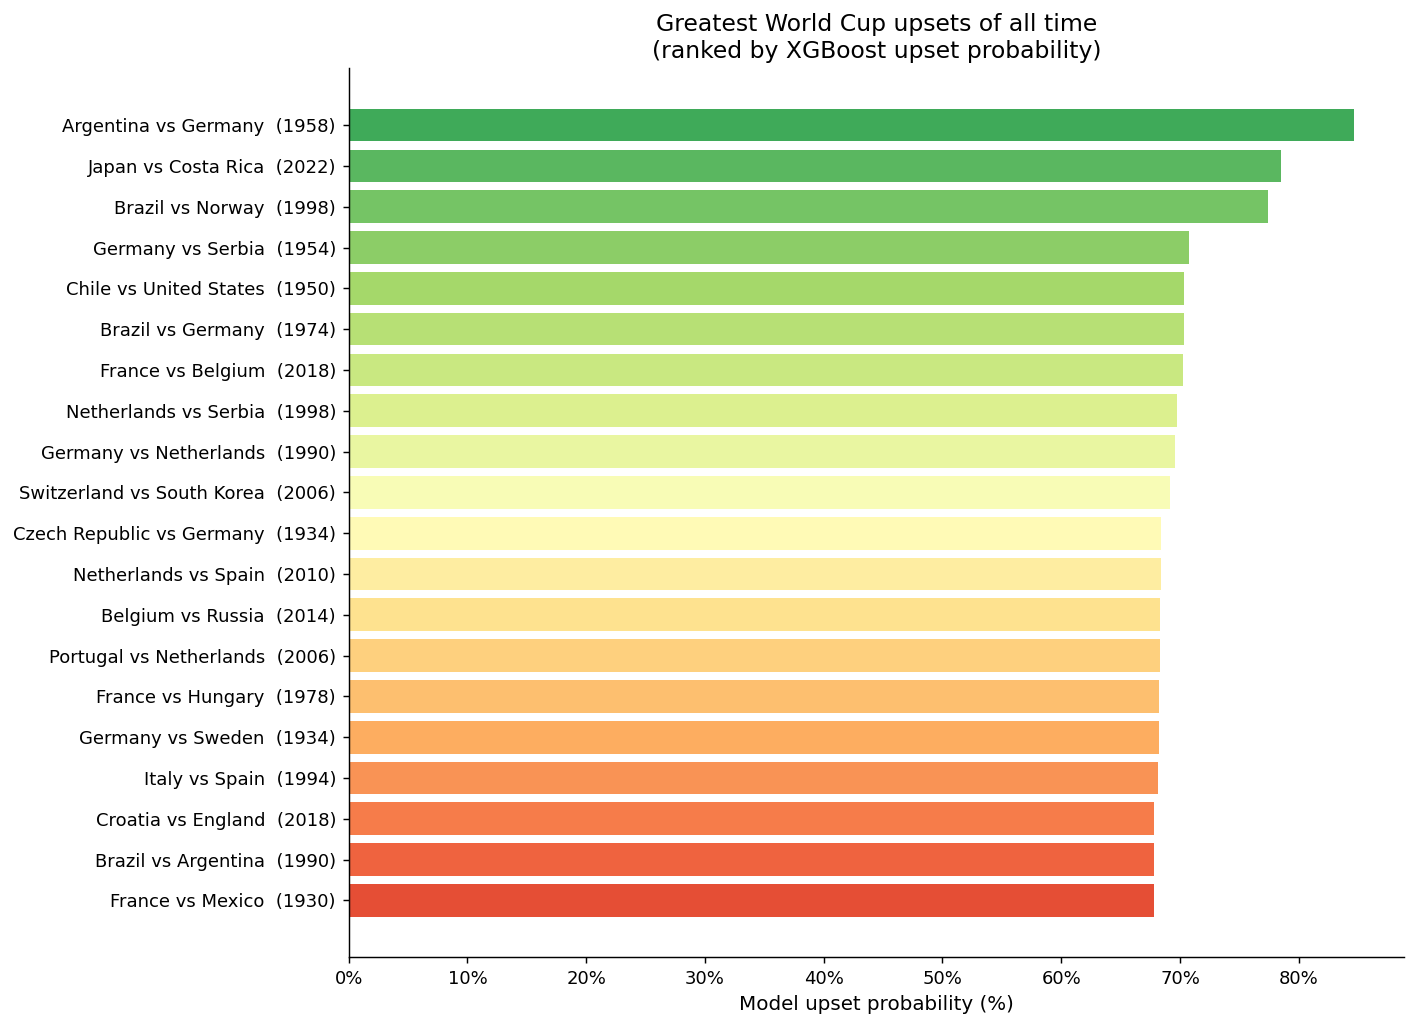

In [13]:
all_features = df[FEATURE_COLS].dropna()
df.loc[all_features.index, 'model_upset_prob'] = xgb.predict_proba(all_features)[:, 1]

wc_upsets = df[
    (df['target'] == 1) &
    df['tournament'].str.contains('FIFA World Cup', na=False) &
    ~df['tournament'].str.contains('qualif', case=False, na=False)
].copy()

wc_upsets['match'] = wc_upsets.apply(
    lambda r: f"{r['home_team']} vs {r['away_team']}", axis=1
)
top_upsets = wc_upsets.sort_values('model_upset_prob', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    top_upsets['match'] + '  (' + top_upsets['date'].dt.year.astype(str) + ')',
    top_upsets['model_upset_prob'] * 100,
    color=plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(top_upsets)))
)
ax.set_xlabel('Model upset probability (%)', fontsize=11)
ax.set_title('Greatest World Cup upsets of all time\n(ranked by XGBoost upset probability)', fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('top_upsets.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Predict any match

In [14]:
import sys
import os
sys.path.insert(0, os.getcwd())

from elo_engine import EloEngine, get_k_factor, confederation_k_multiplier, get_confederation, expected_score

results_df = pd.read_csv('results.csv')
engine = EloEngine()
engine.fit(results_df)
print('Engine ready.')

Dropped 72 rows with missing scores.
Replayed 49,365 matches. 333 unique teams rated.
Mean reversion applied at 22 WC cycles: [1930, 1934, 1938, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
Engine ready.


In [15]:
def predict_match(home_team, away_team, neutral=True, tournament='FIFA World Cup'):
    r_home = engine.rating(home_team)
    r_away = engine.rating(away_team)
    r_home_eff = r_home + (0 if neutral else 100)

    p_home     = expected_score(r_home_eff, r_away)
    conf_mult  = confederation_k_multiplier(home_team, away_team)
    same_conf  = int(
        get_confederation(home_team) == get_confederation(away_team)
        and get_confederation(home_team) is not None
    )
    t_k = get_k_factor(tournament) * conf_mult

    features = pd.DataFrame([{
        'elo_diff':      r_home - r_away,
        'form_elo_diff': r_home - r_away,   # proxy; real value needs window recompute
        'conf_k_mult':   conf_mult,
        'same_conf':     same_conf,
        'is_neutral':    int(neutral),
        'tournament_k':  t_k,
        'pre_prob_home': p_home,
    }])

    upset_prob = xgb.predict_proba(features)[0][1]
    favorite   = home_team if p_home >= 0.5 else away_team
    underdog   = away_team if p_home >= 0.5 else home_team

    print(f"\n{'─'*42}")
    print(f"  {home_team}  vs  {away_team}")
    print(f"  Venue    : {'Neutral' if neutral else home_team + ' (home)'}")
    print(f"  ELO      : {r_home:.0f} vs {r_away:.0f}")
    print(f"  Favorite : {favorite}")
    print(f"  Underdog : {underdog}")
    print(f"  Win prob : {home_team} {p_home*100:.1f}%  /  {away_team} {(1-p_home)*100:.1f}%")
    print(f"  Upset prob (underdog wins): {upset_prob*100:.1f}%")
    print(f"{'─'*42}")


predict_match('Brazil',       'Germany',    neutral=True)
predict_match('Japan',        'Spain',      neutral=True)   # happened in 2022!
predict_match('Saudi Arabia', 'Argentina',  neutral=True)   # 2022 upset
predict_match('England',      'France',     neutral=False)


──────────────────────────────────────────
  Brazil  vs  Germany
  Venue    : Neutral
  ELO      : 1914 vs 1881
  Favorite : Brazil
  Underdog : Germany
  Win prob : Brazil 54.7%  /  Germany 45.3%
  Upset prob (underdog wins): 50.8%
──────────────────────────────────────────

──────────────────────────────────────────
  Japan  vs  Spain
  Venue    : Neutral
  ELO      : 1914 vs 2080
  Favorite : Spain
  Underdog : Japan
  Win prob : Japan 27.8%  /  Spain 72.2%
  Upset prob (underdog wins): 46.7%
──────────────────────────────────────────

──────────────────────────────────────────
  Saudi Arabia  vs  Argentina
  Venue    : Neutral
  ELO      : 1671 vs 2032
  Favorite : Argentina
  Underdog : Saudi Arabia
  Win prob : Saudi Arabia 11.1%  /  Argentina 88.9%
  Upset prob (underdog wins): 8.6%
──────────────────────────────────────────

──────────────────────────────────────────
  England  vs  France
  Venue    : England (home)
  ELO      : 1995 vs 2020
  Favorite : England
  Underdog : F